# ***Automotive CAN Bus Simulator & Analyzer***

In [27]:
import time
import threading
import random
from dataclasses import dataclass
from typing import List
import matplotlib.pyplot as plt

# **CAN Frame Definition**

In [28]:
@dataclass
class CANFrame:
    can_id: int
    data: List[int]
    timestamp: float

    def to_dict(self):
        return {
            "id": hex(self.can_id),
            "data": self.data,
            "timestamp": self.timestamp
        }


def create_frame(can_id, data):
    return CANFrame(
        can_id=can_id,
        data=data,
        timestamp=time.time()
    )

# **Virtual CAN Bus**

In [29]:
class VirtualCANBus:

    def __init__(self):
        self.messages = []
        self.lock = threading.Lock()

    def send(self, frame):
        with self.lock:
            self.messages.append(frame)

    def receive_all(self):
        with self.lock:
            data = self.messages.copy()
            self.messages.clear()
        return data

# **ECU Simulators**

In [30]:
class EngineECU(threading.Thread):

    def __init__(self, bus, vehicle):
        super().__init__()
        self.bus = bus
        self.vehicle = vehicle
        self.running = True

    def run(self):
        while self.running:
            rpm = int(self.vehicle.rpm)
            data = [rpm >> 8, rpm & 0xFF]
            frame = create_frame(0x100, data)
            self.bus.send(frame)
            time.sleep(0.1)

    def stop(self):
        self.running = False

Battery ECU (Voltage)

In [31]:
class BatteryECU(threading.Thread):

    def __init__(self, bus, vehicle):
        super().__init__()
        self.bus = bus
        self.vehicle = vehicle
        self.running = True

    def run(self):
        while self.running:
            voltage = int(self.vehicle.voltage * 100)
            data = [voltage >> 8, voltage & 0xFF]
            frame = create_frame(0x101, data)
            self.bus.send(frame)
            time.sleep(0.5)

    def stop(self):
        self.running = False

Speed ECU

In [32]:
class SpeedECU(threading.Thread):

    def __init__(self, bus, vehicle):
        super().__init__()
        self.bus = bus
        self.vehicle = vehicle
        self.running = True

    def run(self):
        while self.running:
            speed = int(self.vehicle.speed)
            data = [speed]
            frame = create_frame(0x102, data)
            self.bus.send(frame)
            time.sleep(0.1)

    def stop(self):
        self.running = False

Temperature ECU

In [33]:
class TemperatureECU(threading.Thread):

    def __init__(self, bus, vehicle):
        super().__init__()
        self.bus = bus
        self.vehicle = vehicle
        self.running = True

    def run(self):
        while self.running:
            temp = int(self.vehicle.temperature)
            data = [temp]
            frame = create_frame(0x103, data)
            self.bus.send(frame)
            time.sleep(1)

    def stop(self):
        self.running = False

# **CAN Analyzer (Capture)**

In [43]:
class CANAnalyzer:

    def __init__(self, bus):
        self.bus = bus

    def capture(self):
        frames = self.bus.receive_all()
        return frames

# **Signal Decoder**

In [44]:
class SignalDecoder:

    def decode(self, frame):
        if frame.can_id == 0x100:  # RPM
            rpm = (frame.data[0] << 8) | frame.data[1]
            return ("RPM", rpm)

        elif frame.can_id == 0x101:  # Voltage
            value = (frame.data[0] << 8) | frame.data[1]
            voltage = value / 100.0
            return ("Voltage", voltage)

        elif frame.can_id == 0x102:  # Speed
            speed = frame.data[0]
            return ("Speed", speed)

        elif frame.can_id == 0x103:
            temp = frame.data[0]
            return ("Temp", temp)

        return ("Unknown", None)

# **Start Simulation**

In [52]:
class VehicleModel:

    def __init__(self):
        self.speed = 0          # km/h
        self.rpm = 800         # idle RPM
        self.voltage = 12.6
        self.temperature = 70  # °C
        self.throttle = 0.3    # 0 to 1

    def update(self):

        # Driving phases
        phase = int(time.time()) % 20

        if phase < 5:
            # Idle
            self.throttle = 0.1
        elif phase < 10:
            # Acceleration
            self.throttle = 0.7
        elif phase < 15:
            # Cruise
            self.throttle = 0.3
        else:
            # Braking
            self.throttle = 0.0

        # Physics
        acceleration = self.throttle * 8 - 0.15 * self.speed
        self.speed += acceleration
        self.speed = max(0, min(120, self.speed))

          # Gear effect
        # ✅ Gear logic (ADD HERE)
        if self.speed < 20:
            gear_ratio = 60
        elif self.speed < 40:
            gear_ratio = 40
        elif self.speed < 80:
            gear_ratio = 30
        else:
            gear_ratio = 20

        # ✅ Base RPM calculation
        self.rpm = int(800 + self.speed * gear_ratio * (0.6 + self.throttle))

        # ✅ Gear shift drop (ADD HERE)
        if random.random() < 0.05:
            self.rpm = int(self.rpm * 0.85)

        # Voltage
        self.voltage = 12.5 + random.uniform(-0.1, 0.1)

        # Temperature
        # 🌡️ REALISTIC ENGINE TEMPERATURE MODEL

        ambient_temp = 25  # starting temp (cold engine)

        # Engine load factor (based on RPM)
        load = self.rpm / 4000

        # Warm-up behavior
        if self.temperature < 90:
            # Heat up faster when engine is working
            self.temperature += 0.1 + 0.2 * load
        else:
            # Stabilize around operating temp
            self.temperature += random.uniform(-0.05, 0.05)

        # Cooling effect when idle
        if self.speed < 5:
            self.temperature -= 0.05

        # Clamp realistic range
        self.temperature = max(ambient_temp, min(105, self.temperature))
        self.temperature = min(110, self.temperature)

In [53]:
def format_frame(frame, signal, value):

    # Convert data to hex format
    data_hex = [f"0x{byte:02x}" for byte in frame.data]

    if signal == "RPM":
        return f"ID: {hex(frame.can_id)} | Data: {data_hex} | RPM: {value}"

    elif signal == "Speed":
        return f"ID: {hex(frame.can_id)} | Data: {data_hex} | Speed: {value} km/h"

    elif signal == "Voltage":
        return f"ID: {hex(frame.can_id)} | Data: {data_hex} | Voltage: {value:.2f} V"

    elif signal == "Temp":
        return f"ID: {hex(frame.can_id)} | Data: {data_hex} | Temp: {value} °C"

    else:
        return f"ID: {hex(frame.can_id)} | Data: {data_hex} | Unknown"

In [54]:
bus = VirtualCANBus()

vehicle = VehicleModel()   # create FIRST

engine = EngineECU(bus, vehicle)
battery = BatteryECU(bus, vehicle)
speed = SpeedECU(bus, vehicle)
temp_ecu = TemperatureECU(bus, vehicle)

engine.start()
battery.start()
speed.start()
temp_ecu.start()

analyzer = CANAnalyzer(bus)
decoder = SignalDecoder()

# **Data Storage**

In [55]:

rpm_data = []
speed_data = []
voltage_data = []
time_axis = []
temp_data = []

# **Run Simulation + Decode**

In [56]:
start_time = time.time()

for i in range(200):

    vehicle.update()

    frames = analyzer.capture()

    if frames:
        print("\n--- CAN BUS TRAFFIC ---")

    for frame in frames:
        signal, value = decoder.decode(frame)

        # 🔥 PROFESSIONAL OUTPUT
        print(format_frame(frame, signal, value))

        # Store data
        if signal == "RPM":
            rpm_data.append(value)
        elif signal == "Speed":
            speed_data.append(value)
        elif signal == "Voltage":
            voltage_data.append(value)
        elif signal == "Temp":
            temp_data.append(value)

    time.sleep(0.1)


--- CAN BUS TRAFFIC ---
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x101 | Data: ['0x04', '0xec'] | Voltage: 12.60 V
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x103 | Data: ['0x46'] | Temp: 70 °C
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x101 | Data: ['0x04', '0xec'] | Voltage: 12.60 V
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x100 | Data: ['0x03', '0x20'] | RPM: 800
ID: 0x102 | Data: ['0x00'] | Speed: 0 km/h
ID: 0x100 | Data: ['0x03'

# **Stop Threads**

In [57]:
engine.stop()
battery.stop()
speed.stop()

engine.join()
battery.join()
speed.join()

# **Visualization**

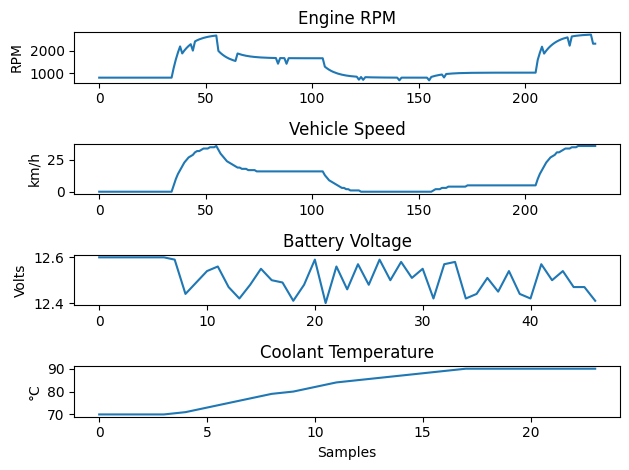

In [58]:
plt.figure()

plt.subplot(4, 1, 1)
plt.plot(rpm_data)
plt.title("Engine RPM")
plt.ylabel("RPM")

plt.subplot(4, 1, 2)
plt.plot(speed_data)
plt.title("Vehicle Speed")
plt.ylabel("km/h")

plt.subplot(4, 1, 3)
plt.plot(voltage_data)
plt.title("Battery Voltage")
plt.ylabel("Volts")

plt.subplot(4, 1, 4)
plt.plot(temp_data)
plt.title("Coolant Temperature")
plt.ylabel("°C")

plt.xlabel("Samples")

plt.tight_layout()
plt.show()